# Chapter 16. PennyLane × PyTorch 연동

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 학습 목표
- `qml.qnn.TorchLayer`로 양자 회로를 `nn.Module`로 만들기
- PyTorch autograd가 양자-고전 경계를 통과하는 모습 직접 확인
- PyTorch optimizer로 양자 회로 학습

In [6]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)
print(f'PyTorch: {torch.__version__}')
print(f'PennyLane: {qml.__version__}')

PyTorch: 2.7.0
PennyLane: 0.42.3


## 16.1 TorchLayer로 양자 회로 만들기
회로를 정의할 때 `interface='torch'`만 지정하면 끝이다.

In [2]:
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def qcircuit(inputs, weights):
    # inputs: PyTorch 텐서, weights: 학습 가능한 텐서
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# TorchLayer로 감싸기
weight_shapes = {'weights': (n_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(qcircuit, weight_shapes)
print(qlayer)
print(f'학습 가능 파라미터 수: {sum(p.numel() for p in qlayer.parameters())}')

<Quantum Torch Layer: func=qcircuit>
학습 가능 파라미터 수: 8


## 16.2 PyTorch 모듈처럼 호출하기

In [3]:
# 배치 입력
x_batch = torch.randn(5, n_qubits)
y_batch = qlayer(x_batch)
print(f'입력 shape: {x_batch.shape}')
print(f'출력 shape: {y_batch.shape}')
print(f'출력 dtype: {y_batch.dtype}')

입력 shape: torch.Size([5, 4])
출력 shape: torch.Size([5, 4])
출력 dtype: torch.float32


## 16.3 다른 nn.Module과 결합
TorchLayer는 `nn.Sequential`이나 `forward` 안에서 자유롭게 결합할 수 있다.

In [4]:
# CNN, Linear와 양자 layer를 sequential로 결합
model = nn.Sequential(
    nn.Linear(10, n_qubits),  # 차원 축소: 10 → 4
    nn.Tanh(),
    qlayer,                    # 양자 레이어
    nn.Linear(n_qubits, 2),   # 분류 헤드
)

x = torch.randn(8, 10)
logits = model(x)
print(f'전체 모델 출력: {logits.shape}')
print(model)

전체 모델 출력: torch.Size([8, 2])
Sequential(
  (0): Linear(in_features=10, out_features=4, bias=True)
  (1): Tanh()
  (2): <Quantum Torch Layer: func=qcircuit>
  (3): Linear(in_features=4, out_features=2, bias=True)
)


## 16.4 autograd 동작 확인
양자-고전 경계를 통과하는 gradient를 직접 확인해본다.

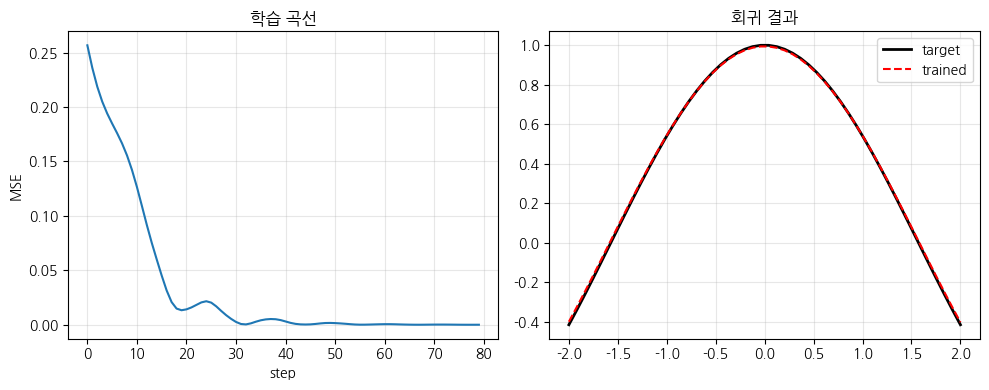

In [7]:
# 작은 회귀 예제: cos 함수 학습
x_data = torch.linspace(-2, 2, 50).unsqueeze(1)
y_data = torch.cos(x_data)

# 단순 하이브리드 모델
n_q = 3
dev2 = qml.device('default.qubit', wires=n_q)

@qml.qnode(dev2, interface='torch')
def regression_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_q))
    qml.BasicEntanglerLayers(weights, wires=range(n_q))
    return qml.expval(qml.PauliZ(0))

qreg = qml.qnn.TorchLayer(
    regression_circuit, {'weights': (2, n_q)}
)

model = nn.Sequential(
    nn.Linear(1, n_q),
    qreg,
)

opt = torch.optim.Adam(model.parameters(), lr=0.05)
history = []
for step in range(80):
    opt.zero_grad()
    pred = model(x_data).unsqueeze(1)
    loss = ((pred - y_data) ** 2).mean()
    loss.backward()  # autograd가 양자-고전 경계를 통과
    opt.step()
    history.append(loss.item())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history); plt.title('학습 곡선')
plt.xlabel('step'); plt.ylabel('MSE')
plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(x_data.squeeze(), y_data, 'k-', label='target', lw=2)
with torch.no_grad():
    plt.plot(x_data.squeeze(), model(x_data), 'r--', label='trained')
plt.legend(); plt.grid(alpha=0.3); plt.title('회귀 결과')
plt.tight_layout(); plt.show()

**해석.** PyTorch optimizer가 양자 회로의 파라미터까지 자동으로 학습시킨다. `loss.backward()` 한 줄로 chain rule이 양자-고전 경계를 완벽히 통과한다.

## 16.5 정리
- `qml.qnn.TorchLayer`로 양자 회로를 `nn.Module`로 변환
- `nn.Sequential` 안에 자유롭게 끼워넣을 수 있음
- PyTorch autograd와 optimizer가 양자 회로의 학습을 그대로 처리
- 다음 장에서 이 도구로 본격적인 하이브리드 모델을 만든다.